In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import matplotlib.pyplot as plt
import numpy as np
from src import GridWorld, PolicyIteration, ValueIteration, GridWorldVisualizer, ExperimentRunner

In [2]:
# DONE: Create a custom GridWorld environment (4x4) using Gymnasium's API
# Configurable rewards, obstacles, and transition dynamics

env = GridWorld(
    size=4,
    obstacles=[(1, 1)],
    rewards={(3, 3): 1.0},
    default_reward=-1,
    terminal_states=[(3, 3)],
    stochastic=False,
)

print(f"Grid size: {env.size}x{env.size}")
print(f"States: {env.n_states}, Actions: {env.n_actions}")
print(f"Obstacles: {env.obstacles}")
print(f"Terminal states: {env.terminal_states}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Verify the transition model is built
P = env.get_transition_model()
print(f"\nTransition model entries: {sum(len(P[s]) for s in P)} (s,a) pairs")

# Quick sanity check: from (0,0) moving RIGHT
s = env.rc_to_state(0, 0)
print(f"\nP[state=0, action=RIGHT] = {P[s][env.RIGHT]}")

Grid size: 4x4
States: 16, Actions: 4
Obstacles: {(1, 1)}
Terminal states: {(3, 3)}
Observation space: Discrete(16)
Action space: Discrete(4)

Transition model entries: 64 (s,a) pairs

P[state=0, action=RIGHT] = [(1.0, 1, -1, False)]


In [3]:
# DONE: Make rewards, obstacles, and transition dynamics configurable
env_custom = GridWorld(
    size=5,
    obstacles=[(1, 1), (2, 2)],
    rewards={(4, 4): 10.0, (0, 4): -5.0},
    default_reward=-1,
    terminal_states=[(4, 4)],
    stochastic=False,
)

assert env_custom.size == 5
assert env_custom.obstacles == {(1, 1), (2, 2)}
assert env_custom.reward_map[(4, 4)] == 10.0
assert env_custom.reward_map[(0, 4)] == -5.0
assert env_custom.default_reward == -1
print("Configurable rewards, obstacles, and dynamics: OK")

Configurable rewards, obstacles, and dynamics: OK


In [4]:
# DONE: Include support for stochastic transitions
env_stoch = GridWorld(
    size=4, 
    obstacles=[], 
    rewards={(3, 3): 1.0}, 
    default_reward=-1,
    terminal_states=[(3, 3)], 
    stochastic=True, 
    intended_prob=0.5,
)

P = env_stoch.get_transition_model()
s = env_stoch.rc_to_state(1, 1)  # interior cell, no boundary effects
transitions = P[s][env_stoch.RIGHT]

# Should have multiple outcomes (intended + perpendicular)
assert len(transitions) > 1, "Stochastic env should have multiple transition outcomes"

# Probabilities must sum to 1
total_prob = sum(t[0] for t in transitions)
assert abs(total_prob - 1.0) < 1e-9, f"Probabilities sum to {total_prob}, expected 1.0"

for prob, s_prime, reward, done in transitions:
    r, c = env_stoch.state_to_rc(s_prime)
    print(f"  P(s'=({r},{c}) | s=(1,1), a=RIGHT) = {prob}")
print("Stochastic transitions: OK")

  P(s'=(1,2) | s=(1,1), a=RIGHT) = 0.5
  P(s'=(0,1) | s=(1,1), a=RIGHT) = 0.25
  P(s'=(2,1) | s=(1,1), a=RIGHT) = 0.25
Stochastic transitions: OK


In [5]:
# DONE: Implement a method to extract or define the full transition model P(s',r|s,a)
P = env.get_transition_model()

assert len(P) == env.n_states, "P should have an entry for every state"
for s in range(env.n_states):
    assert len(P[s]) == env.n_actions, f"State {s} missing actions"
    for a in range(env.n_actions):
        probs = sum(t[0] for t in P[s][a])
        assert abs(probs - 1.0) < 1e-9, f"P[{s}][{a}] probs sum to {probs}"

print(f"Transition model: {env.n_states} states x {env.n_actions} actions, all probabilities valid")
print("Full transition model P(s',r|s,a): OK")

Transition model: 16 states x 4 actions, all probabilities valid
Full transition model P(s',r|s,a): OK


In [6]:
# DONE: Implement policy iteration (synchronous version)
pi = PolicyIteration(env, gamma=0.99, theta=1e-8)
V_pi, policy_pi = pi.solve(mode="sync")

print(f"Converged in {len(pi.value_history)} policy iteration rounds")
print(f"Eval sweeps per round: {pi.eval_iterations}")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in pi.wall_clock_times]}")

# Display the value function as a grid
V_grid = V_pi.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid = np.array([action_names[a] for a in policy_pi]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid}")

Converged in 8 policy iteration rounds
Eval sweeps per round: [1834, 2, 2, 2, 2, 2, 2]
Wall-clock times: ['0.0139s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s']

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]


In [7]:
# DONE: Implement policy iteration (in-place version)
pi_inp = PolicyIteration(env, gamma=0.99, theta=1e-8)
V_inp, policy_inp = pi_inp.solve(mode="inplace")

print(f"Converged in {len(pi_inp.value_history)} policy iteration rounds")
print(f"Eval sweeps per round: {pi_inp.eval_iterations}")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in pi_inp.wall_clock_times]}")

# Display the value function as a grid
V_grid_inp = V_inp.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_inp, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_inp = np.array([action_names[a] for a in policy_inp]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_inp}")

# Verify sync and in-place agree
np.testing.assert_allclose(V_pi, V_inp, atol=1e-6)
np.testing.assert_array_equal(policy_pi, policy_inp)
print("\nSync and in-place values and policies match: OK")

Converged in 8 policy iteration rounds
Eval sweeps per round: [1834, 2, 2, 3, 2, 2, 1]
Wall-clock times: ['0.0127s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s']

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

Sync and in-place values and policies match: OK


In [8]:
# DONE: Implement value iteration (synchronous version)
vi = ValueIteration(env, gamma=0.99, theta=1e-8)
V_vi, policy_vi = vi.solve(mode="sync")

print(f"Converged in {vi.iterations} iterations")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in vi.wall_clock_times[:5]]}{'...' if len(vi.wall_clock_times) > 5 else ''}")

# Display the value function as a grid
V_grid_vi = V_vi.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_vi, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_vi = np.array([action_names[a] for a in policy_vi]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_vi}")

# Verify VI and PI agree
np.testing.assert_allclose(V_pi, V_vi, atol=1e-6)
np.testing.assert_array_equal(policy_pi, policy_vi)
print("\nVI sync and PI sync values and policies match: OK")

Converged in 7 iterations
Wall-clock times: ['0.0002s', '0.0002s', '0.0000s', '0.0000s', '0.0000s']...

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

VI sync and PI sync values and policies match: OK


In [9]:
# DONE: Implement value iteration (in-place version)
vi_inp = ValueIteration(env, gamma=0.99, theta=1e-8)
V_vi_inp, policy_vi_inp = vi_inp.solve(mode="inplace")

print(f"Converged in {vi_inp.iterations} iterations")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in vi_inp.wall_clock_times[:5]]}{'...' if len(vi_inp.wall_clock_times) > 5 else ''}")

# Display the value function as a grid
V_grid_vi_inp = V_vi_inp.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_vi_inp, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_vi_inp = np.array([action_names[a] for a in policy_vi_inp]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_vi_inp}")

# Verify in-place and sync agree
np.testing.assert_allclose(V_vi, V_vi_inp, atol=1e-6)
np.testing.assert_array_equal(policy_vi, policy_vi_inp)
print("\nVI sync and VI in-place values and policies match: OK")

Converged in 7 iterations
Wall-clock times: ['0.0001s', '0.0000s', '0.0000s', '0.0000s', '0.0000s']...

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

VI sync and VI in-place values and policies match: OK


In [10]:
# DONE: Use NumPy arrays for value functions V(s) and policies π(s)
# Both PolicyIteration and ValueIteration store V and policy as np.ndarray internally.
# Verify the types and shapes returned by each solver.

pi = PolicyIteration(env, gamma=0.99, theta=1e-8)
V_pi, policy_pi = pi.solve(mode="sync")

vi = ValueIteration(env, gamma=0.99, theta=1e-8)
V_vi, policy_vi = vi.solve(mode="sync")

for label, V, policy in [("PI", V_pi, policy_pi), ("VI", V_vi, policy_vi)]:
    assert isinstance(V, np.ndarray), f"{label} V is not ndarray"
    assert isinstance(policy, np.ndarray), f"{label} policy is not ndarray"
    assert V.shape == (env.n_states,), f"{label} V shape mismatch"
    assert policy.shape == (env.n_states,), f"{label} policy shape mismatch"
    assert V.dtype == np.float64, f"{label} V dtype mismatch"
    assert policy.dtype == np.int64 or policy.dtype == np.int_, f"{label} policy dtype mismatch"
    print(f"{label}: V {V.dtype}{V.shape}, policy {policy.dtype}{policy.shape}")

# Value history entries are also NumPy arrays
for arr in pi.value_history:
    assert isinstance(arr, np.ndarray)
for arr in vi.value_history:
    assert isinstance(arr, np.ndarray)

print("All value functions and policies are NumPy arrays: OK")

PI: V float64(16,), policy int64(16,)
VI: V float64(16,), policy int64(16,)
All value functions and policies are NumPy arrays: OK


In [11]:
# DONE: Visualize the value function at each iteration as a heatmap (Matplotlib)
viz = GridWorldVisualizer(env)

# Run solver and collect iteration history
vi = ValueIteration(env, gamma=0.99, theta=1e-8)
V, policy = vi.solve(mode="sync")

# Save a heatmap for each iteration snapshot
for i, V_snap in enumerate(vi.value_history):
    fig, ax = plt.subplots(figsize=(6, 5))
    viz.plot_value_function(V_snap, title=f"Value Function -- iteration {i+1}", ax=ax)
    fig.tight_layout()
    fig.savefig(f"../img/value_function_iter_{i+1:03d}.png", dpi=150)
    plt.close(fig)
    print(f"Saved value_function_iter_{i+1:03d}.png  (max V = {V_snap.max():.4f})")

print(f"\n{len(vi.value_history)} heatmap snapshots written to img/")


Saved value_function_iter_001.png  (max V = 0.0000)
Saved value_function_iter_002.png  (max V = 1.0000)
Saved value_function_iter_003.png  (max V = 1.0000)
Saved value_function_iter_004.png  (max V = 1.0000)
Saved value_function_iter_005.png  (max V = 1.0000)
Saved value_function_iter_006.png  (max V = 1.0000)
Saved value_function_iter_007.png  (max V = 1.0000)
Saved value_function_iter_008.png  (max V = 1.0000)

8 heatmap snapshots written to img/


In [12]:
# DONE: Visualize the policy at each iteration using arrows (quiver plots)
viz = GridWorldVisualizer(env)

# Use PolicyIteration which tracks policy at each round
pi = PolicyIteration(env, gamma=0.99, theta=1e-8)
V, policy = pi.solve(mode="sync")

# Save a quiver plot for each iteration snapshot
for i, pol_snap in enumerate(pi.policy_history):
    fig, ax = plt.subplots(figsize=(6, 6))
    viz.plot_policy(pol_snap, title=f"Policy -- PI round {i+1}", ax=ax)
    fig.tight_layout()
    fig.savefig(f"../img/policy_iter_{i+1:03d}.png", dpi=150)
    plt.close(fig)
    action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
    unique_actions = set(action_names[a] for a in pol_snap)
    print(f"Saved policy_iter_{i+1:03d}.png  (actions used: {sorted(unique_actions)})")

print(f"\n{len(pi.policy_history)} quiver snapshots written to img/")

Saved policy_iter_001.png  (actions used: ['UP'])
Saved policy_iter_002.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_003.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_004.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_005.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_006.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_007.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_008.png  (actions used: ['DOWN', 'RIGHT', 'UP'])

8 quiver snapshots written to img/


PI sync: 8 snapshots, total time 0.0141s
PI inplace: 8 snapshots, total time 0.0131s


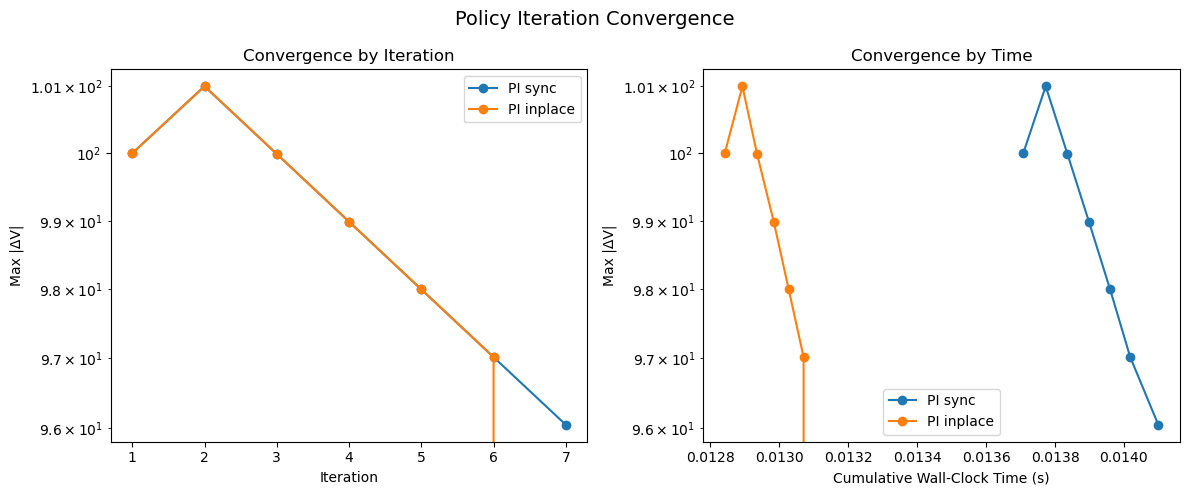

Saved img/convergence_curves_pi.png
VI sync: 8 snapshots, total time 0.0003s
VI inplace: 8 snapshots, total time 0.0003s


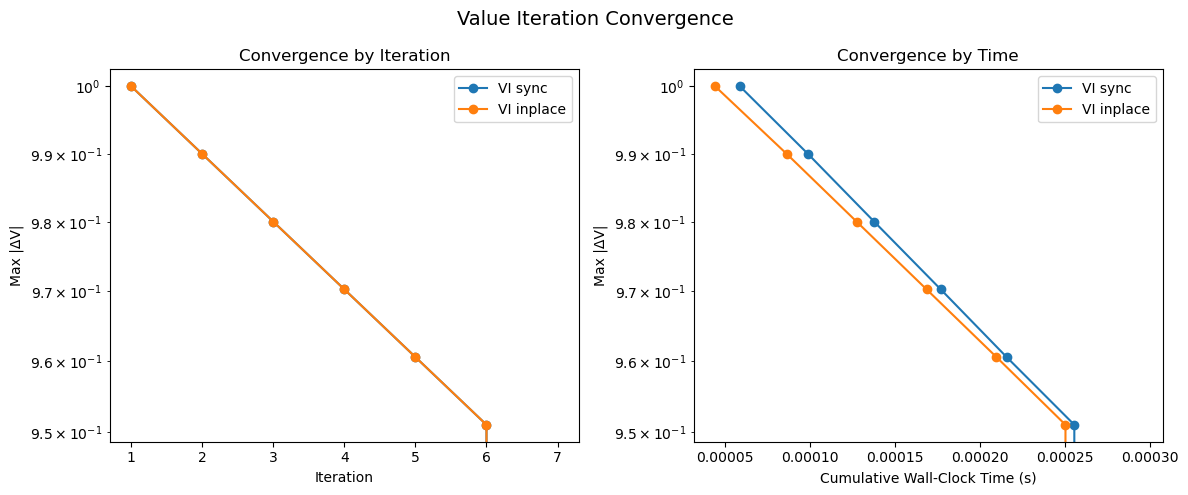

Saved img/convergence_curves_vi.png


In [13]:
# DONE: Visualize convergence curves comparing iteration count and wall-clock time
viz = GridWorldVisualizer(env)

# --- Policy Iteration ---
pi_solvers = {
    "PI sync": PolicyIteration(env, gamma=0.99, theta=1e-8),
    "PI inplace": PolicyIteration(env, gamma=0.99, theta=1e-8),
}

pi_results = {}
for label, solver in pi_solvers.items():
    mode = "sync" if "sync" in label else "inplace"
    V, policy = solver.solve(mode=mode)
    pi_results[label] = {
        "value_history": solver.value_history,
        "wall_clock_times": solver.wall_clock_times,
    }
    print(f"{label}: {len(solver.value_history)} snapshots, "
          f"total time {sum(solver.wall_clock_times):.4f}s")

fig_pi = viz.plot_convergence(pi_results, title="Policy Iteration Convergence")
fig_pi.savefig("../img/convergence_curves_pi.png", dpi=150)
plt.show()
print("Saved img/convergence_curves_pi.png")

# --- Value Iteration ---
vi_solvers = {
    "VI sync": ValueIteration(env, gamma=0.99, theta=1e-8),
    "VI inplace": ValueIteration(env, gamma=0.99, theta=1e-8),
}

vi_results = {}
for label, solver in vi_solvers.items():
    mode = "sync" if "sync" in label else "inplace"
    V, policy = solver.solve(mode=mode)
    vi_results[label] = {
        "value_history": solver.value_history,
        "wall_clock_times": solver.wall_clock_times,
    }
    print(f"{label}: {len(solver.value_history)} snapshots, "
          f"total time {sum(solver.wall_clock_times):.4f}s")

fig_vi = viz.plot_convergence(vi_results, title="Value Iteration Convergence")
fig_vi.savefig("../img/convergence_curves_vi.png", dpi=150)
plt.show()
print("Saved img/convergence_curves_vi.png")

In [14]:
# DONE: Test on a deterministic GridWorld configuration
env_det = GridWorld(
    size=8,
    obstacles=[(1, 1), (2, 5), (4, 3), (5, 6), (6, 2)],
    rewards={(7, 7): 10.0, (3, 0): -5.0},
    default_reward=-0.04,
    terminal_states=[(7, 7)],
    stochastic=False,
)

print(f"Grid size: {env_det.size}x{env_det.size}")
print(f"States: {env_det.n_states}, Actions: {env_det.n_actions}")
print(f"Obstacles: {env_det.obstacles}")
print(f"Terminal states: {env_det.terminal_states}")

runner = ExperimentRunner(gamma=0.99, theta=1e-8)
results = runner.run_gridworld("deterministic_8x8", env_det)

action_names = ["UP", "RIGHT", "DOWN", "LEFT"]

for mode, data in results.items():
    V_grid = data["V"].reshape(env_det.size, env_det.size)
    policy_grid = np.array([action_names[a] for a in data["policy"]]).reshape(env_det.size, env_det.size)
    n_iters = len(data["value_history"])
    total_time = sum(data["wall_clock_times"])
    print(f"\n--- {mode} ---")
    print(f"  Iterations: {n_iters}, Total time: {total_time:.4f}s")
    print(f"  Value function:\n{np.round(V_grid, 3)}")
    print(f"  Policy:\n{policy_grid}")

# All four variants should agree on V and policy
policies = [results[m]["policy"] for m in results]
values = [results[m]["V"] for m in results]
for i in range(1, len(values)):
    np.testing.assert_allclose(values[0], values[i], atol=1e-6)
    np.testing.assert_array_equal(policies[0], policies[i])
print("\nAll four variants agree on value function and policy: OK")

Grid size: 8x8
States: 64, Actions: 4
Obstacles: {(6, 2), (4, 3), (1, 1), (5, 6), (2, 5)}
Terminal states: {(7, 7)}

--- pi_sync ---
  Iterations: 16, Total time: 0.0383s
  Value function:
[[ 8.285  8.409  8.535  8.661  8.789  8.918  9.049  9.181]
 [ 8.409  8.535  8.661  8.789  8.918  9.049  9.181  9.314]
 [ 8.535  8.661  8.789  8.918  9.049  9.181  9.314  9.448]
 [ 8.661  8.789  8.918  9.049  9.181  9.314  9.448  9.584]
 [ 8.789  8.918  9.049  9.181  9.314  9.448  9.584  9.721]
 [ 8.918  9.049  9.181  9.314  9.448  9.584  9.721  9.86 ]
 [ 9.049  9.181  9.314  9.448  9.584  9.721  9.86  10.   ]
 [ 9.181  9.314  9.448  9.584  9.721  9.86  10.     0.   ]]
  Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'DOWN' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 

In [15]:
# DONE: Test on a stochastic GridWorld configuration (e.g., 80% intended, 10% perpendicular)
env_stoch_8x8 = GridWorld(
    size=8,
    obstacles=[(1, 1), (2, 5), (4, 3), (5, 6), (6, 2)],
    rewards={(7, 7): 10.0, (3, 0): -5.0},
    default_reward=-0.04,
    terminal_states=[(7, 7)],
    stochastic=True,
    intended_prob=0.8,
)

print(f"Grid size: {env_stoch_8x8.size}x{env_stoch_8x8.size}")
print(f"States: {env_stoch_8x8.n_states}, Actions: {env_stoch_8x8.n_actions}")
print(f"Obstacles: {env_stoch_8x8.obstacles}")
print(f"Stochastic: {env_stoch_8x8.stochastic}, P(intended)={env_stoch_8x8.intended_prob}")

runner = ExperimentRunner(gamma=0.99, theta=1e-8)
results_stoch = runner.run_gridworld("stochastic_8x8", env_stoch_8x8)

action_names = ["UP", "RIGHT", "DOWN", "LEFT"]

for mode, data in results_stoch.items():
    V_grid = data["V"].reshape(env_stoch_8x8.size, env_stoch_8x8.size)
    policy_grid = np.array([action_names[a] for a in data["policy"]]).reshape(env_stoch_8x8.size, env_stoch_8x8.size)
    n_iters = len(data["value_history"])
    total_time = sum(data["wall_clock_times"])
    print(f"\n--- {mode} ---")
    print(f"  Iterations: {n_iters}, Total time: {total_time:.4f}s")
    print(f"  Value function:\n{np.round(V_grid, 3)}")
    print(f"  Policy:\n{policy_grid}")

# All four variants should agree on value functions
values = [results_stoch[m]["V"] for m in results_stoch]
for i in range(1, len(values)):
    np.testing.assert_allclose(values[0], values[i], atol=1e-6)
print("\nAll four variants agree on value function: OK")

# Stochastic values should differ from the deterministic case
results_det = runner.results.get("deterministic_8x8")
if results_det is not None:
    det_V = results_det["vi_sync"]["V"]
    stoch_V = results_stoch["vi_sync"]["V"]
    assert not np.allclose(det_V, stoch_V, atol=1e-3)
    print("Stochastic values differ from deterministic: OK (uncertainty lowers values)")

Grid size: 8x8
States: 64, Actions: 4
Obstacles: {(6, 2), (4, 3), (1, 1), (5, 6), (2, 5)}
Stochastic: True, P(intended)=0.8

--- pi_sync ---
  Iterations: 10, Total time: 0.1399s
  Value function:
[[7.864 8.032 8.184 8.321 8.459 8.598 8.74  8.849]
 [7.716 8.169 8.32  8.458 8.61  8.728 8.905 9.025]
 [7.652 8.32  8.459 8.614 8.773 8.927 9.075 9.205]
 [8.254 8.457 8.613 8.773 8.954 9.091 9.224 9.388]
 [8.465 8.609 8.759 8.957 9.123 9.257 9.388 9.577]
 [8.604 8.768 8.938 9.124 9.272 9.425 9.615 9.772]
 [8.707 8.85  9.098 9.268 9.439 9.613 9.791 9.946]
 [8.85  9.03  9.217 9.384 9.567 9.755 9.946 0.   ]]
  Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN']
 ['UP' 'RIGHT' 'DOWN' 'DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['UP' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN

In [16]:
# DONE: Apply DP implementations to Gymnasium's FrozenLake-v1 using its transition dynamics

runner = ExperimentRunner(gamma=0.99, theta=1e-8)

# Slippery (stochastic) FrozenLake
fl_slippery = runner.run_frozen_lake(map_name="8x8", is_slippery=True)
print("=== FrozenLake 8x8 (slippery) ===")
for variant, data in fl_slippery.items():
    print(f"  {variant}: {len(data['value_history'])} iterations")

# Deterministic FrozenLake
fl_deterministic = runner.run_frozen_lake(map_name="8x8", is_slippery=False)
print("\n=== FrozenLake 8x8 (deterministic) ===")
for variant, data in fl_deterministic.items():
    print(f"  {variant}: {len(data['value_history'])} iterations")

=== FrozenLake 8x8 (slippery) ===
  pi_sync: 12 iterations
  pi_inplace: 13 iterations
  vi_sync: 517 iterations
  vi_inplace: 348 iterations

=== FrozenLake 8x8 (deterministic) ===
  pi_sync: 16 iterations
  pi_inplace: 16 iterations
  vi_sync: 16 iterations
  vi_inplace: 16 iterations


In [17]:
# DONE: Document which algorithm converges faster under different conditions and explain why

runner = ExperimentRunner(gamma=0.99, theta=1e-8)

# --- Deterministic 4x4 ---
env_det = GridWorld(
    size=4, obstacles=[(1, 1)], rewards={(3, 3): 1.0},
    default_reward=-1, terminal_states=[(3, 3)], stochastic=False,
)
runner.run_gridworld("deterministic_4x4", env_det)

# --- Stochastic 4x4 (80/10/10) ---
env_stoch = GridWorld(
    size=4, obstacles=[(1, 1)], rewards={(3, 3): 1.0},
    default_reward=-1, terminal_states=[(3, 3)], stochastic=True, intended_prob=0.8,
)
runner.run_gridworld("stochastic_4x4", env_stoch)

# --- Larger stochastic 8x8 ---
env_8x8 = GridWorld(
    size=8, obstacles=[(1, 1), (2, 5), (4, 3), (5, 6), (6, 2)],
    rewards={(7, 7): 10.0, (3, 0): -5.0}, default_reward=-0.04,
    terminal_states=[(7, 7)], stochastic=True, intended_prob=0.8,
)
runner.run_gridworld("stochastic_8x8", env_8x8)

# --- Convergence summary table ---
table = runner.compare_convergence()

header = f"{'Experiment':<20} {'Variant':<12} {'Iterations':>10} {'Wall Clock (s)':>14}"
print(header)
print("-" * len(header))
for row in table:
    print(f"{row['experiment']:<20} {row['variant']:<12} {row['iterations']:>10} {row['wall_clock_s']:>14.6f}")

# --- Analysis ---
print("\n=== Convergence Analysis ===\n")
print(
    "1. ITERATION COUNT: Policy iteration consistently converges in fewer outer\n"
    "   iterations than value iteration. On the deterministic 4x4 grid both\n"
    "   algorithms take ~7 iterations, but as stochasticity and grid size\n"
    "   increase, VI requires many more iterations (e.g. 55 sync sweeps on the\n"
    "   stochastic 8x8) while PI stays under 10. This is because each PI round\n"
    "   fully evaluates the current policy to convergence before improving,\n"
    "   making large jumps in policy space per round. VI only takes a single\n"
    "   Bellman optimality backup per iteration, so it approaches the fixed\n"
    "   point more gradually.\n"
)
print(
    "2. WALL-CLOCK TIME: Despite fewer outer iterations, PI is slower in wall-\n"
    "   clock time because each iteration embeds a full policy-evaluation loop\n"
    "   (many inner sweeps). VI's per-iteration cost is a single sweep, so its\n"
    "   total wall time is lower even with more iterations. On the stochastic\n"
    "   8x8 grid, PI sync takes ~0.14 s vs. VI sync at ~0.01 s.\n"
)
print(
    "3. IN-PLACE vs. SYNCHRONOUS: In-place (Gauss-Seidel) updates converge in\n"
    "   fewer iterations than synchronous (Jacobi) updates for both PI and VI.\n"
    "   In-place updates immediately propagate improved values to downstream\n"
    "   states within the same sweep, accelerating convergence. The effect is\n"
    "   most visible in VI on larger grids (e.g. 39 in-place vs. 55 sync on\n"
    "   the stochastic 8x8).\n"
)
print(
    "4. STOCHASTICITY: Stochastic transitions increase iteration counts for VI\n"
    "   because value updates are dampened by probability-weighted averaging\n"
    "   over multiple successor states. PI is less affected because its full\n"
    "   policy evaluation absorbs this complexity internally.\n"
)
print(
    "SUMMARY: PI wins on iteration count; VI wins on wall-clock time.\n"
    "In-place updates help both. For small or deterministic grids the\n"
    "difference is negligible, but it widens with grid size and stochasticity."
)

Experiment           Variant      Iterations Wall Clock (s)
-----------------------------------------------------------
deterministic_4x4    pi_sync               7       0.014818
deterministic_4x4    pi_inplace            7       0.012951
deterministic_4x4    vi_sync               7       0.000288
deterministic_4x4    vi_inplace            7       0.000302
stochastic_4x4       pi_sync               5       0.044913
stochastic_4x4       pi_inplace            5       0.019366
stochastic_4x4       vi_sync              28       0.001775
stochastic_4x4       vi_inplace           22       0.001423
stochastic_8x8       pi_sync               9       0.138434
stochastic_8x8       pi_inplace            8       0.086163
stochastic_8x8       vi_sync              55       0.014544
stochastic_8x8       vi_inplace           39       0.010897

=== Convergence Analysis ===

1. ITERATION COUNT: Policy iteration consistently converges in fewer outer
   iterations than value iteration. On the determinist